# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Sanchez Varela Agustín**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
# Instalo las dependencias necesarias
! pip install requests beautifulsoup4 html5lib
!python -m spacy download es_core_news_sm

import sys
print(sys.executable)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 49.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
/usr/bin/python3


#1.1 Verificación de la conexión con la página

En este bloque se realiza una petición HTTP a la URL del artículo mediante la biblioteca `requests`. Luego, se comprueba que la respuesta del servidor sea correcta utilizando `raise_for_status()`.

El código HTML obtenido se procesa con `BeautifulSoup`, lo que permite buscar y extraer elementos específicos de la página. Primero se localiza el artículo mediante la etiqueta `<article>` y después se recuperan su título y sus párrafos.

Finalmente, la información se almacena en un diccionario llamado `contenido`, compuesto por:

- `titulo`: título principal del artículo.
- `parrafos`: lista con los párrafos encontrados.
- `texto_completo`: unión de todos los párrafos en una sola cadena de texto.

In [ ]:
# requests descarga la página y BeautifulSoup permite recorrer su HTML
import requests
from bs4 import BeautifulSoup


url = "https://larevuelta.com.ar/2026/09/05/olvidense-de-los-pechos/"

# Hago la consulta y freno con un error claro si la página no responde bien
respuesta = requests.get(url, timeout=15)
respuesta.raise_for_status()

# Convierto el HTML recibido en una estructura que se puede buscar
soup = BeautifulSoup(respuesta.text, "html.parser")


# Busco el contenedor principal
articulo = soup.find("article")

if articulo:

    titulo = articulo.find("h1")

    parrafos = [
        parrafo.get_text(" ", strip=True)
        for parrafo in articulo.find_all("p")
        if parrafo.get_text(strip=True)
    ]

    # Guardo todo en un diccionario para reutilizarlo en el preprocesamiento
    contenido = {
        "titulo": titulo.get_text(" ", strip=True) if titulo else "",
        "parrafos": parrafos,
        "texto_completo": "\n\n".join(parrafos)
    }

    print(contenido["titulo"])
    print(contenido["texto_completo"])
else:
    print("No se encontró el artículo.")

OLVÍDENSE DE LOS PECHOS
Por Mónica Reynoso.-

“Me veo como una mujer pero pienso como un hombre. A veces soy la única mujer en una sala de reuniones. Entonces digo: olvídense de los pechos y escuchen lo que tengo para decir”.

No sólo era un asunto de pechos descomunales que ella amontonaba en escotes como balcón abierto a la mirada. Era ropa bien apretada y escasa y chillona, brillos, lentejuelas, puntillas, el repertorio del vestir más barroco y estridente bajo una cabellera rubísima y alta y empalagosa como una Copa Melba, ojos verdes imposibles subrayados con kilómetros de pestañas, maquillaje y más maquillaje. Una verdadera muñeca, una dolly real. Así lucía Dolly Parton. Hasta que hablaba.

Una periodista, seria y genuinamente preocupada, le pregunta por qué se vestía de esa manera “extrema”, si era hermosa y no lo necesitaba. Y Dolly: “ Decidí que haría algo para llamar la atención. Esto es showbusiness , una broma para ganar dinero y siempre me ha gustado contar chistes. Sé que 

## 2- Preprocesamiento

### 2.1 Identificación de stop words

Primero se carga el modelo `es_core_news_sm` de SpaCy. Este modelo separa el texto en tokens, obtiene el lema de cada palabra y marca las stop words, es decir, palabras muy frecuentes que generalmente no aportan significado temático.

Antes de analizarlo se excluyen el primer y el noveno párrafo porque corresponden a información periférica del artículo. Luego se arma una tabla de control con la forma original, el lema y la marca de stop word de cada token. Así se puede verificar qué elementos se van a conservar en los pasos siguientes.

In [ ]:
# Cargo SpaCy en español para tokenizar, lematizar y detectar stop words
import spacy
import pandas as pd
nlp = spacy.load("es_core_news_sm")

In [ ]:
# Dejo afuera los parrafos 1 y 9 porque no aportan al analisis del contenido
parrafos_filtrados = [p for i, p in enumerate(contenido["parrafos"]) if i not in [0, 8]]

# Uno los parrafos elegidos y los proceso con el modelo de español
doc = nlp(" ".join(parrafos_filtrados))

# Armo una tabla para revisar palabra original, lema y si SpaCy la marca como stop word
limpieza_spacy = [
    {
        "original": token.text,
        "lemma": token.lemma_,
        "es_stopword": token.is_stop,
    }

    for token in doc if not token.is_punct and not token.is_space

]


limpieza_df = pd.DataFrame(limpieza_spacy)
limpieza_df


,original,lemma,es_stopword
0,Me,yo,True
1,veo,ver,False
2,como,como,True
3,una,uno,True
4,mujer,mujer,False
...,...,...,...
1378,caracteres,caracter,False
1379,color,color,False
1380,rosa,rosa,False
1381,Y,y,True


### 2.2 Limpieza del texto y nube de palabras

Para la nube se descartan stop words, signos de puntuación, espacios y tokens que no sean palabras alfabéticas. En lugar de usar la forma exacta de cada palabra, se usa su lema en minúsculas; por ejemplo, distintas conjugaciones de un verbo quedan agrupadas.

Con el resultado se generan dos nubes usando la biblioteca `wordcloud`. La segunda suma una lista corta de exclusiones detectadas al revisar la primera visualización, de modo que las palabras vinculadas al tema del artículo se lean mejor.

In [ ]:
# Conservo solamente palabras alfabeticas, sin stop words ni puntuación
palabras_limpias = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space

]

# Uno la lista en un texto que despues se usa para la nube de palabras
texto_limpio = " ".join(palabras_limpias)

print(texto_limpio)

ver mujer pensar hombre único mujer sala reunión decir olvídense pecho escuchen asunto pecho descomunal amontonar escot balcón abierto mirada ropa apretado escaso chillona brillo lentejuela puntilla repertorio vestir barroco estridente cabellera rubísima alto empalagós copa melba ojo verde imposible subrayado kilómetro pestaña maquillaje maquillaje muñeca dolly real lucir dolly parton hablar periodista serio genuinamente preocupado preguntar vestir extremo hermoso necesitar dolly decidí hacer llamar atención showbusiness broma ganar dinero gustar contar chiste burlar superar shock ver yo ridícula ver parte valer pena auténtico rebajar moda fácil gustar extraordinario vida cesar martes 25 agosto nashville llamado ciudad música cuna country honor empire state vestir rosa guardia real británico interpretar éxito musical donald trump decretar semana bandera medio asta gente común ciento mil dollies despedir desfile barbie rosa chicle imperante profusa melena dorada bota tejana blanco carro

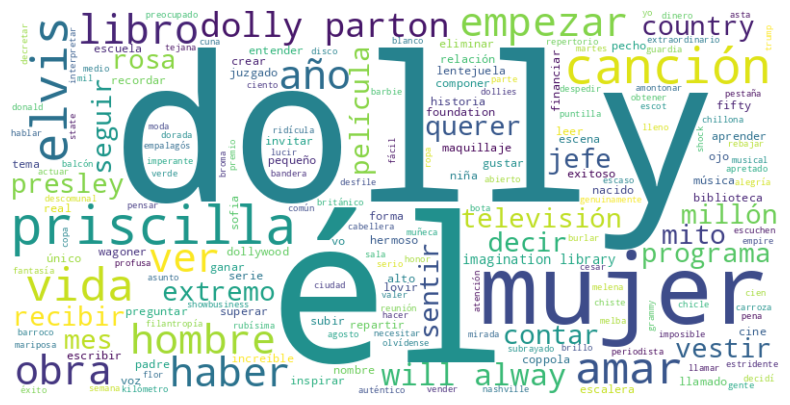

In [ ]:
# WordCloud genera la visualización y matplotlib la muestra en el notebook
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# La primera nube usa todas las palabras que quedaron luego de la limpieza
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_limpio)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

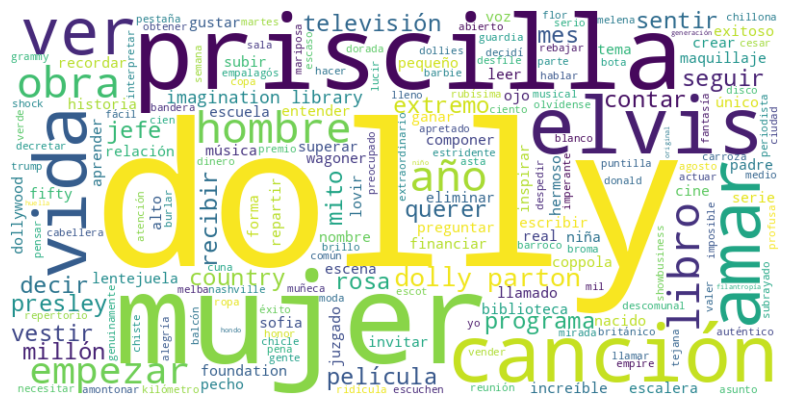

In [ ]:
# Estas palabras siguen apareciendo pero no describen el tema central del artículo
exclusiones = ["haber", "él", "i", "will", "alway", "so", "vo", "you", "always", "state"]
# Genero una segunda nube sin esas palabras para que se destaquen los términos relevantes
wordcloud_sin_stops = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=exclusiones
).generate(texto_limpio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_sin_stops, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.

Se reutiliza el documento obtenido en los puntos anteriores. Cada oración se toma como un documento: así, la limpieza se aplica sin perder la relación entre los términos de una misma oración. La matriz resultante tendrá una fila por oración y una columna por término del vocabulario.

Se eliminan las oraciones que quedan vacías después de la limpieza. A continuación, `CountVectorizer` arma la matriz documento-vocabulario: cada celda muestra cuántas veces aparece un término en una oración.

In [25]:

# SpaCy separa el texto en oraciones; cada una va a funcionar como un documento
oraciones_spacy = [oracion.text.strip() for oracion in doc.sents]


# Repito la limpieza dentro de cada oracion para conservar esa division
documentos_limpios = [
    " ".join(
        token.lemma_.lower()
        for token in oracion
        if token.is_alpha
        and not token.is_stop
        and not token.is_punct
        and not token.is_space
    )
    for oracion in doc.sents
]


# Descarto oraciones que hayan quedado vacias después de eliminar stopwords
documentos_limpios = [documento for documento in documentos_limpios if documento]

print(f"Cantidad de oraciones: {len(oraciones_spacy)}")
print(f"Documentos listos para la matriz: {len(documentos_limpios)}")


Cantidad de oraciones: 74
Documentos listos para la matriz: 74


In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

# Aprendo el vocabulario del corpus y calculo cuantas veces aparece cada palabra por oracion
vectorizador = CountVectorizer()
matriz_documento_vocabulario = vectorizador.fit_transform(documentos_limpios)
vocabulario = vectorizador.get_feature_names_out()

# Paso la matriz a DataFrame para leer filas y columnas con mas facilidad
matriz_dv_df = pd.DataFrame(
    matriz_documento_vocabulario.toarray(),
    index=[f"Oración {i + 1}" for i in range(len(documentos_limpios))],
    columns=vocabulario
)

matriz_dv_df


,abandona,abierto,acabar,aceptar,actuar,acumular,admirar,adorar,agosto,agua,...,víctima,vínculo,wagoner,whitney,will,yo,you,él,éxito,único
Oración 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Oración 3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Oración 70,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
Oración 71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 72,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Longitud del vocabulario

El vocabulario contiene los términos únicos encontrados por `CountVectorizer` luego del preprocesamiento. Su longitud indica cuántas palabras distintas se usan como columnas en la matriz documento-vocabulario.

In [ ]:
# Cuento los terminos unicos que quedaron despues de limpiar el texto
longitud_vocabulario = len(vocabulario)
print(f"Longitud del vocabulario: {longitud_vocabulario} palabras")


Longitud del vocabulario: 485 palabras



#### 2.3.3 Aplicación de TF-IDF

TF-IDF reemplaza los conteos simples por pesos. Un término recibe más peso cuando ayuda a distinguir una oración del resto del texto y menos peso cuando se repite en muchas oraciones. Al final se suman los pesos por término para identificar cuáles son los más representativos del corpus.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Calculo los pesos TF-IDF usando los mismos documentos ya limpios
tfidf_vectorizador = TfidfVectorizer()
matriz_tfidf = tfidf_vectorizador.fit_transform(documentos_limpios)

# Lo convierto a DataFrame para poder inspeccionar cada peso
matriz_tfidf_df = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=[f"Oración {i + 1}" for i in range(len(documentos_limpios))],
    columns=tfidf_vectorizador.get_feature_names_out()
)
# Sumo los pesos de cada termino y ordeno para ver los diez mas representativos
pesos_palabras = matriz_tfidf_df.sum(axis=0).sort_values(ascending=False)

print(pesos_palabras.head(10))

matriz_tfidf_df.head(10)

dolly        3.524917
él           2.195826
amar         2.052761
mujer        1.977561
priscilla    1.974384
canción      1.675266
ver          1.669944
elvis        1.582723
parton       1.258018
hombre       1.241818
dtype: float64


,abandona,abierto,acabar,aceptar,actuar,acumular,admirar,adorar,agosto,agua,...,víctima,vínculo,wagoner,whitney,will,yo,you,él,éxito,único
Oración 1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500502
Oración 3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 4,0.0,0.357318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 5,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 6,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 7,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 8,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 9,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
Oración 10,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


## Formato de las matrices

En la matriz documento-vocabulario, cada fila representa una oración del artículo y cada columna un lema distinto del vocabulario limpio. El valor de una celda indica cuántas veces aparece ese término en esa oración. La matriz TF-IDF conserva las mismas filas y columnas, pero reemplaza los conteos por pesos: un término obtiene mayor peso cuando es relevante para una oración y menos frecuente en las demás.

El último bloque de código informa las dimensiones de ambas matrices. Como se construyen a partir del mismo conjunto de oraciones y vocabulario, tienen igual cantidad de filas y columnas, aunque sus valores tienen interpretaciones diferentes.

# Conclusiones

El web scraping permitió obtener el texto del artículo y el preprocesamiento eliminó puntuación, espacios, stopwords y tokens no alfabéticos. Usar lemas unifica variantes de una misma palabra, por ejemplo verbos conjugados, y hace más representativa tanto la nube de palabras como la matriz. La representación por oraciones permite observar qué términos aparecen en cada parte del texto; TF-IDF reduce la influencia de las palabras frecuentes y destaca las más características de cada oración.

In [ ]:
# Informo el tamaño final de las dos representaciones del corpus
filas, columnas = matriz_dv_df.shape
print(f"Matriz documento-vocabulario: {filas} documentos (oraciones) × {columnas} términos.")
print(f"Matriz TF-IDF: {matriz_tfidf_df.shape[0]} documentos × {matriz_tfidf_df.shape[1]} términos.")


Matriz documento-vocabulario: 74 documentos (oraciones) × 485 términos.
Matriz TF-IDF: 74 documentos × 485 términos.
